# Análise Exploratória — ENEM 2018–2022 + IVS / IDHM



## 0. Configuração


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path.cwd()
YEARS = [2018, 2019, 2020, 2021, 2022]
SAMPLE = 200_000   # linhas por ano para as distribuições
def arq(y): return BASE / f'microdados_enem_{y}' / 'DADOS' / f'MICRODADOS_ENEM_{y}.csv'
assert arq(2018).exists(), 'Ajuste BASE: a pasta deve conter microdados_enem_2018 ... _2022'

NOTAS = ['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO']
PRES  = ['TP_PRESENCA_CN','TP_PRESENCA_CH','TP_PRESENCA_LC','TP_PRESENCA_MT']
COLS  = ['NU_ANO','TP_SEXO','TP_COR_RACA','TP_FAIXA_ETARIA','TP_ESCOLA','SG_UF_PROVA',
         'Q001','Q002','Q006','Q024','Q025'] + NOTAS + PRES

SEXO = {'M':'Masculino','F':'Feminino'}
RACA = {0:'Não declarado',1:'Branca',2:'Preta',3:'Parda',4:'Amarela',5:'Indígena',6:'Não dispõe'}

## 1. Inventário dos arquivos


In [ ]:
import os
inv=[]
for y in YEARS:
    f=arq(y); inv.append([y, f.name, round(f.stat().st_size/1e9,2)])
inv=pd.DataFrame(inv,columns=['Ano','Arquivo','Tamanho_GB'])
inv

,Ano,Arquivo,Tamanho_GB
0,2018,MICRODADOS_ENEM_2018.csv,2.59
1,2019,MICRODADOS_ENEM_2019.csv,2.41
2,2020,MICRODADOS_ENEM_2020.csv,2.02
3,2021,MICRODADOS_ENEM_2021.csv,1.51
4,2022,MICRODADOS_ENEM_2022.csv,1.57


## 2. Estrutura dos microdados (amostra de um ano)


In [ ]:
df22 = pd.read_csv(arq(2022), sep=';', usecols=COLS, encoding='latin-1', nrows=SAMPLE)
print('Formato da amostra:', df22.shape)
print('\nTipos das colunas:'); print(df22.dtypes)
df22.head()

Formato da amostra: (200000, 20)

Tipos das colunas:
NU_ANO               int64
TP_FAIXA_ETARIA      int64
TP_SEXO                str
TP_COR_RACA          int64
TP_ESCOLA            int64
SG_UF_PROVA            str
TP_PRESENCA_CN       int64
TP_PRESENCA_CH       int64
TP_PRESENCA_LC       int64
TP_PRESENCA_MT       int64
NU_NOTA_CN         float64
NU_NOTA_CH         float64
NU_NOTA_LC         float64
NU_NOTA_MT         float64
NU_NOTA_REDACAO    float64
Q001                   str
Q002                   str
Q006                   str
Q024                   str
Q025                   str
dtype: object


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ESCOLA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,Q006,Q024,Q025
0,2022,14,M,2,1,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,A,A,B,A,A
1,2022,14,M,1,1,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,D,D,Q,E,B
2,2022,5,F,2,1,BA,1,1,1,1,421.1,546.0,498.8,565.3,760.0,E,F,B,A,B
3,2022,6,M,3,1,ES,1,1,1,1,490.7,388.6,357.8,416.0,320.0,C,A,A,B,B
4,2022,4,M,3,1,PA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,D,B,B,A,A


## 3. Volume de inscritos por ano (totais reais)


 Ano  Inscritos
2018    5513733
2019    5095171
2020    5783109
2021    3389832
2022    3476105


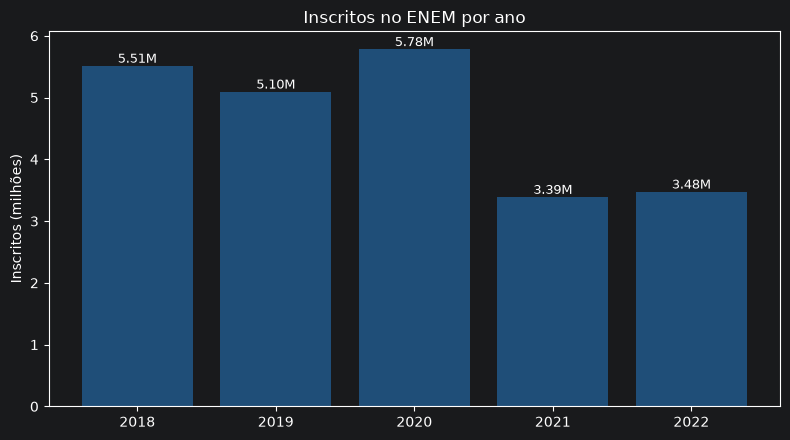

In [ ]:
vol=[]
for y in YEARS:
    n=sum(len(c) for c in pd.read_csv(arq(y), sep=';', usecols=['NU_ANO'], encoding='latin-1', chunksize=1_000_000))
    vol.append([y,n])
vol=pd.DataFrame(vol,columns=['Ano','Inscritos'])
print(vol.to_string(index=False))
fig,ax=plt.subplots(figsize=(8,4.5))
ax.bar(vol['Ano'], vol['Inscritos']/1e6, color='#1f4e78')
for x,v in zip(vol['Ano'], vol['Inscritos']): ax.text(x, v/1e6+0.05, f'{v/1e6:.2f}M', ha='center', fontsize=9)
ax.set_ylabel('Inscritos (milhões)'); ax.set_xticks(YEARS); ax.set_title('Inscritos no ENEM por ano'); plt.tight_layout(); plt.show()

## 4. Amostra combinada para as distribuições


In [ ]:
parts=[pd.read_csv(arq(y), sep=';', usecols=COLS, encoding='latin-1', nrows=SAMPLE) for y in YEARS]
df=pd.concat(parts, ignore_index=True)
print('Amostra combinada:', df.shape, '| anos:', sorted(df['NU_ANO'].unique()))

Amostra combinada: (1000000, 20) | anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


## 5. Perfil demográfico (amostra)


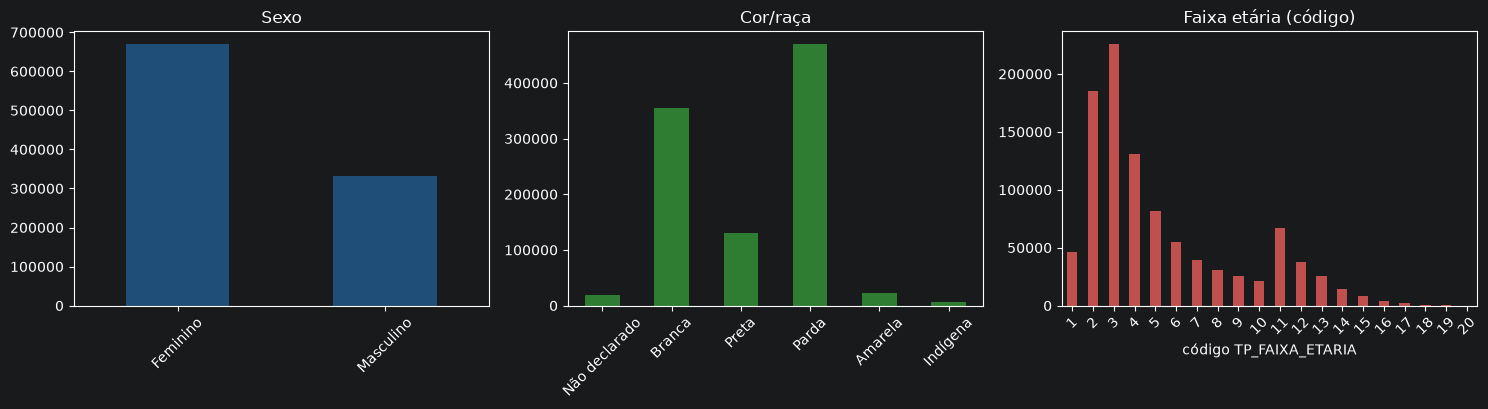

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(15,4.2))
df['TP_SEXO'].map(SEXO).value_counts().plot(kind='bar',ax=axes[0],color='#1f4e78')
axes[0].set_title('Sexo'); axes[0].set_xlabel('')
df['TP_COR_RACA'].map(RACA).value_counts().reindex([v for v in RACA.values() if v in set(df['TP_COR_RACA'].map(RACA))]).plot(kind='bar',ax=axes[1],color='#2e7d32')
axes[1].set_title('Cor/raça'); axes[1].set_xlabel('')
df['TP_FAIXA_ETARIA'].value_counts().sort_index().plot(kind='bar',ax=axes[2],color='#c0504d')
axes[2].set_title('Faixa etária (código)'); axes[2].set_xlabel('código TP_FAIXA_ETARIA')
for a in axes: a.tick_params(axis='x',rotation=45)
plt.tight_layout(); plt.show()

## 6. Notas: distribuição e presença (amostra)


In [ ]:
print('Estatísticas das notas (apenas presentes):')
df[NOTAS].describe().round(1)

Estatísticas das notas (apenas presentes):


,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
count,723337.0,758484.0,758484.0,723337.0,758484.0
mean,491.1,532.6,520.9,531.0,606.7
std,77.6,89.0,73.7,111.7,201.1
min,0.0,0.0,0.0,0.0,0.0
25%,431.7,469.4,474.2,442.3,500.0
50%,481.3,535.6,526.2,512.1,600.0
75%,543.1,597.5,572.7,605.9,760.0
max,869.6,846.9,807.7,994.4,1000.0


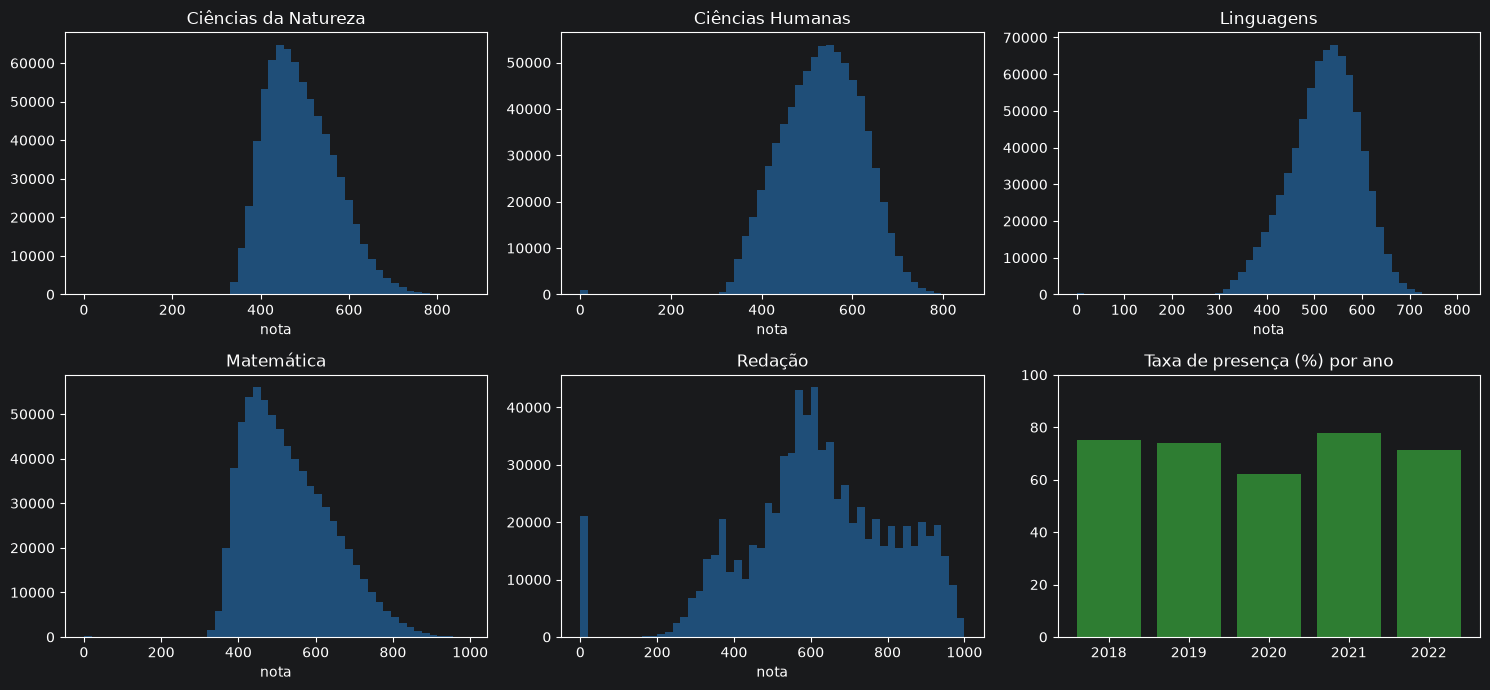

In [ ]:
fig,axes=plt.subplots(2,3,figsize=(15,7)); axes=axes.ravel()
titulos={'NU_NOTA_CN':'Ciências da Natureza','NU_NOTA_CH':'Ciências Humanas','NU_NOTA_LC':'Linguagens','NU_NOTA_MT':'Matemática','NU_NOTA_REDACAO':'Redação'}
for i,c in enumerate(NOTAS):
    axes[i].hist(df[c].dropna(), bins=50, color='#1f4e78'); axes[i].set_title(titulos[c]); axes[i].set_xlabel('nota')
# taxa de presenca por ano (na amostra)
df['PRESENTE']=(df[PRES]==1).all(axis=1)
tx=df.groupby('NU_ANO')['PRESENTE'].mean()*100
axes[5].bar(tx.index.astype(str), tx.values, color='#2e7d32'); axes[5].set_title('Taxa de presença (%) por ano'); axes[5].set_ylim(0,100)
plt.tight_layout(); plt.show()

## 7. Questionário socioeconômico (amostra)


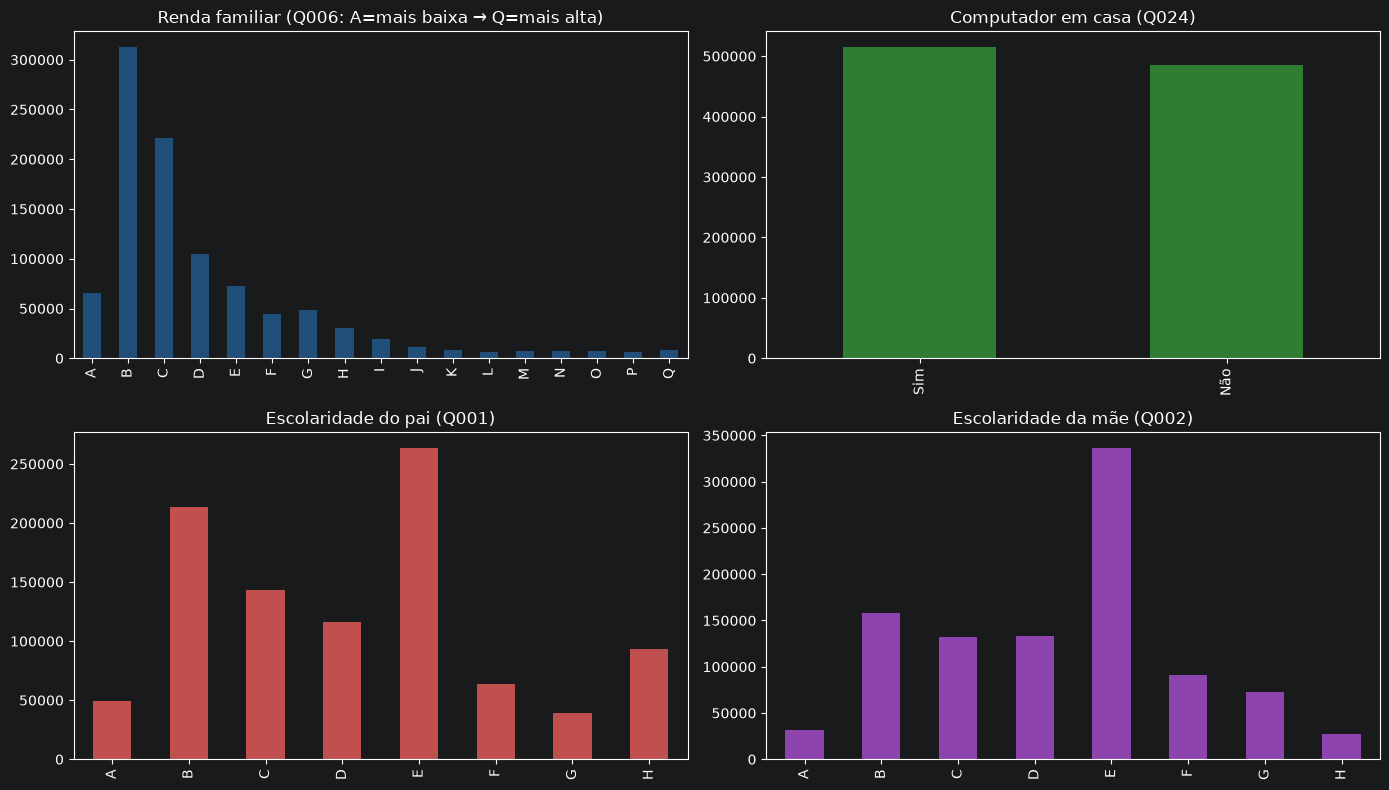

In [ ]:
fig,axes=plt.subplots(2,2,figsize=(14,8))
df['Q006'].value_counts().sort_index().plot(kind='bar',ax=axes[0,0],color='#1f4e78')
axes[0,0].set_title('Renda familiar (Q006: A=mais baixa → Q=mais alta)'); axes[0,0].set_xlabel('')
# computador (Q024: A=Não, demais=Sim) e internet (Q025: A=Não, B=Sim)
comp=np.where(df['Q024']=='A','Não','Sim'); inte=np.where(df['Q025']=='A','Não','Sim')
pd.Series(comp).value_counts().plot(kind='bar',ax=axes[0,1],color='#2e7d32'); axes[0,1].set_title('Computador em casa (Q024)'); axes[0,1].set_xlabel('')
df['Q001'].value_counts().sort_index().plot(kind='bar',ax=axes[1,0],color='#c0504d')
axes[1,0].set_title('Escolaridade do pai (Q001)'); axes[1,0].set_xlabel('')
df['Q002'].value_counts().sort_index().plot(kind='bar',ax=axes[1,1],color='#8e44ad')
axes[1,1].set_title('Escolaridade da mãe (Q002)'); axes[1,1].set_xlabel('')
plt.tight_layout(); plt.show()

## 8. Valores faltantes (amostra)


% de valores faltantes por coluna (>0):
NU_NOTA_CN         27.7
NU_NOTA_MT         27.7
NU_NOTA_LC         24.2
NU_NOTA_CH         24.2
NU_NOTA_REDACAO    24.2
Q025                1.8
Q024                1.8
Q002                1.8
Q006                1.8
Q001                1.8


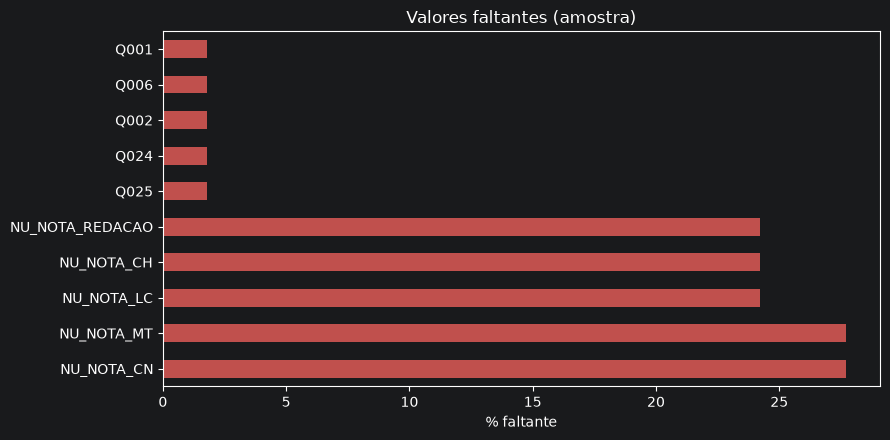

In [ ]:
miss=(df.isna().mean()*100).round(1).sort_values(ascending=False)
miss=miss[miss>0]
print('% de valores faltantes por coluna (>0):')
print(miss.to_string() if len(miss) else 'Nenhum valor faltante nas colunas selecionadas.')
if len(miss):
    fig,ax=plt.subplots(figsize=(9,4.5)); miss.plot(kind='barh',ax=ax,color='#c0504d')
    ax.set_xlabel('% faltante'); ax.set_title('Valores faltantes (amostra)'); plt.tight_layout(); plt.show()

## 9. IVS e IDHM por região (2018–2022)
Fonte: `IVS - Copy.xls` / `IDHM - Copy.xls` (IPEA / Atlas Brasil). Valores fixados abaixo (dados por região).


In [ ]:
regs=['Norte','Nordeste','Centro-Oeste','Sudeste','Sul']
IDHM={'Norte':[0.732,0.732,0.730,0.705,0.747],'Nordeste':[0.723,0.729,0.728,0.713,0.740],
      'Centro-Oeste':[0.790,0.797,0.787,0.767,0.808],'Sudeste':[0.806,0.813,0.803,0.783,0.813],'Sul':[0.795,0.799,0.794,0.774,0.802]}
IVS ={'Norte':[0.285,0.286,0.276,0.297,0.260],'Nordeste':[0.297,0.300,0.303,0.319,0.270],
      'Centro-Oeste':[0.231,0.234,0.240,0.240,0.213],'Sudeste':[0.230,0.224,0.234,0.241,0.204],'Sul':[0.184,0.177,0.186,0.180,0.165]}
idhm_df=pd.DataFrame(IDHM,index=YEARS); ivs_df=pd.DataFrame(IVS,index=YEARS)
print('IDHM por região e ano:'); print(idhm_df.round(3).to_string()); print('\nIVS por região e ano:'); print(ivs_df.round(3).to_string())

IDHM por região e ano:
      Norte  Nordeste  Centro-Oeste  Sudeste    Sul
2018  0.732     0.723         0.790    0.806  0.795
2019  0.732     0.729         0.797    0.813  0.799
2020  0.730     0.728         0.787    0.803  0.794
2021  0.705     0.713         0.767    0.783  0.774
2022  0.747     0.740         0.808    0.813  0.802

IVS por região e ano:
      Norte  Nordeste  Centro-Oeste  Sudeste    Sul
2018  0.285     0.297         0.231    0.230  0.184
2019  0.286     0.300         0.234    0.224  0.177
2020  0.276     0.303         0.240    0.234  0.186
2021  0.297     0.319         0.240    0.241  0.180
2022  0.260     0.270         0.213    0.204  0.165


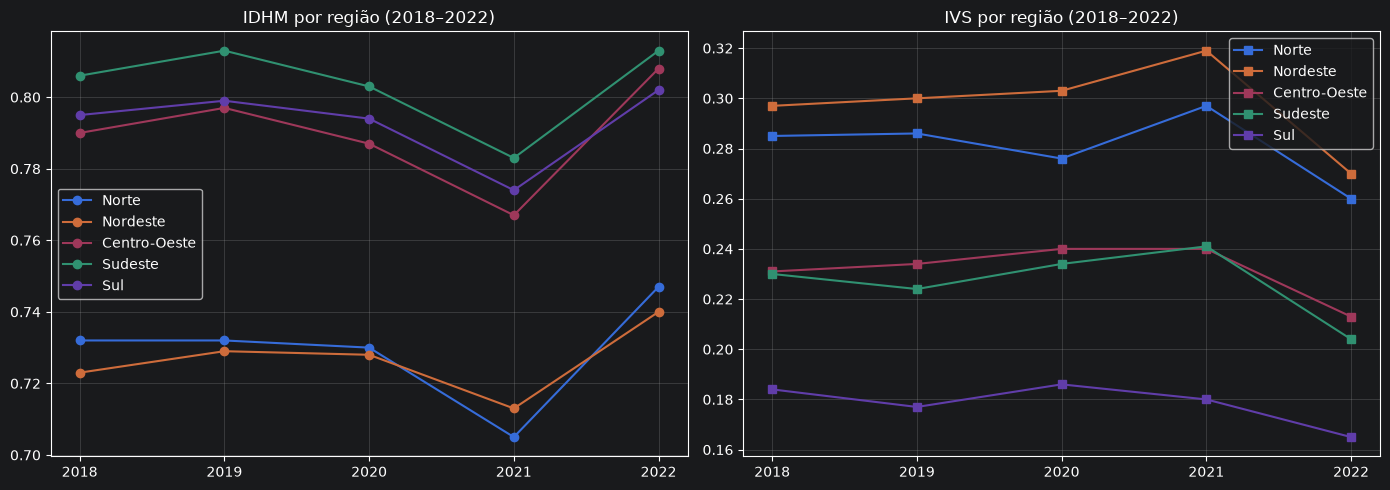

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
for rg in regs: axes[0].plot(YEARS, IDHM[rg], marker='o', label=rg)
axes[0].set_title('IDHM por região (2018–2022)'); axes[0].set_xticks(YEARS); axes[0].legend(); axes[0].grid(alpha=.3)
for rg in regs: axes[1].plot(YEARS, IVS[rg], marker='s', label=rg)
axes[1].set_title('IVS por região (2018–2022)'); axes[1].set_xticks(YEARS); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()